# 🌸 K-Means Clustering sur le Dataset Iris
---

## 📌 Objectif
Ce notebook explore l'algorithme de **clustering K-Means** appliqué au célèbre
dataset **Iris**, en couvrant toutes les étapes d'une analyse complète :

| Étape | Description |
|-------|-------------|
| 1️⃣ | Chargement et préparation des données |
| 2️⃣ | Choix du nombre de clusters (Elbow + Silhouette) |
| 3️⃣ | Entraînement du modèle K-Means |
| 4️⃣ | Visualisation des clusters |
| 5️⃣ | Analyse Silhouette détaillée |
| 6️⃣ | **Comparaison avec les vraies classes** |
| 7️⃣ | Conclusion et interprétation |

---

## 📖 Le Dataset Iris
Le dataset Iris contient **150 échantillons** de fleurs répartis en **3 espèces** :
- 🌺 *Iris Setosa*
- 🌼 *Iris Versicolor*
- 🌸 *Iris Virginica*

Chaque fleur est décrite par **4 mesures** (en cm) :
- Longueur et largeur des **sépales**
- Longueur et largeur des **pétales**

---

## ⚠️ Rappel Important
> K-Means est un algorithme **non supervisé** : il ne connaît **pas** les vraies
> étiquettes. Nous allons mesurer à quel point il les retrouve naturellement.

---
*📅 Notebook réalisé avec : `scikit-learn`, `matplotlib`, `numpy`, `seaborn`*

In [10]:
# ============================================================
#  📦 Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

# Style global
plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = ["#E74C3C", "#2ECC71", "#3498DB"]

In [11]:
# ============================================================
#  📊 Chargement & Préparation des données
# ============================================================
iris = load_iris()
X_full  = iris.data          # 4 features (pour les scores)
X_viz   = iris.data[:, :2]   # 2 features  (pour la visualisation)

# Normalisation
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
X_viz_scaled = scaler.fit_transform(X_viz)

print("✅ Données chargées")
print(f"   • Nombre d'échantillons  : {X_full.shape[0]}")
print(f"   • Nombre de features     : {X_full.shape[1]}")
print(f"   • Classes réelles        : {iris.target_names.tolist()}")

✅ Données chargées
   • Nombre d'échantillons  : 150
   • Nombre de features     : 4
   • Classes réelles        : ['setosa', 'versicolor', 'virginica']


/tmp/ipykernel_9470/3667072413.py:47: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9470/3667072413.py:48: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


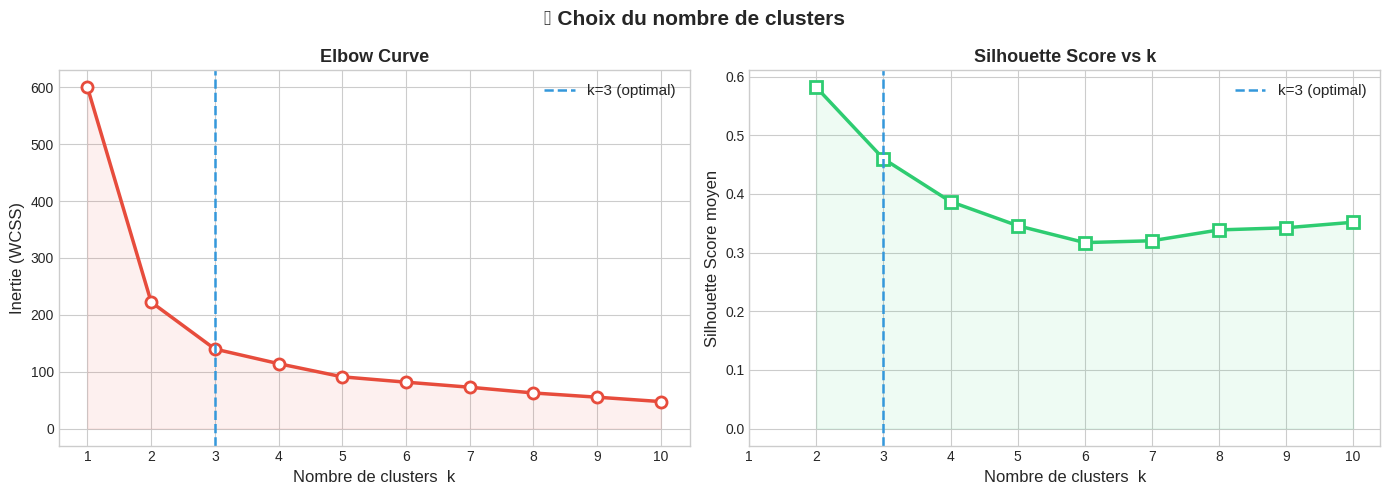

✅ Elbow Curve & Silhouette vs k tracés


In [12]:
# ============================================================
#  📈 Elbow Curve  (inertie vs k)
# ============================================================
K_range   = range(1, 11)
inertias  = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k > 1:                                       # silhouette nécessite k ≥ 2
        sil_scores.append(silhouette_score(X_scaled, km.labels_))
    else:
        sil_scores.append(None)

# ── Tracé ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("🔍 Choix du nombre de clusters", fontsize=15, fontweight="bold")

# --- Elbow ---
ax = axes[0]
ax.plot(K_range, inertias, "o-", color="#E74C3C", linewidth=2.5,
        markersize=8, markerfacecolor="white", markeredgewidth=2)
ax.axvline(x=3, color="#3498DB", linestyle="--", linewidth=1.8, label="k=3 (optimal)")
ax.fill_between(K_range, inertias, alpha=0.08, color="#E74C3C")
ax.set_xlabel("Nombre de clusters  k", fontsize=12)
ax.set_ylabel("Inertie (WCSS)", fontsize=12)
ax.set_title("Elbow Curve", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xticks(list(K_range))

# --- Silhouette vs k ---
ax2 = axes[1]
sil_valid = [(k, s) for k, s in zip(K_range, sil_scores) if s is not None]
ks, ss = zip(*sil_valid)
ax2.plot(ks, ss, "s-", color="#2ECC71", linewidth=2.5,
         markersize=8, markerfacecolor="white", markeredgewidth=2)
ax2.axvline(x=3, color="#3498DB", linestyle="--", linewidth=1.8, label="k=3 (optimal)")
ax2.fill_between(ks, ss, alpha=0.08, color="#2ECC71")
ax2.set_xlabel("Nombre de clusters  k", fontsize=12)
ax2.set_ylabel("Silhouette Score moyen", fontsize=12)
ax2.set_title("Silhouette Score vs k", fontsize=13, fontweight="bold")
ax2.legend(fontsize=11)
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Elbow Curve & Silhouette vs k tracés")

In [13]:
# ============================================================
#  🤖 Entraînement K-Means  k = 3
# ============================================================
K_OPTIMAL = 3

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# ── Scores ─────────────────────────────────────────────────
inertia   = kmeans.inertia_
sil_score = silhouette_score(X_scaled, labels)

print("=" * 45)
print("        📊  RÉSULTATS  K-MEANS  (k=3)")
print("=" * 45)
print(f"  🔵 Inertie  (WCSS)       : {inertia:.2f}")
print(f"  🟢 Silhouette Score      : {sil_score:.4f}  ", end="")
if sil_score >= 0.5:
    print("✅ Bonne séparation")
elif sil_score >= 0.25:
    print("⚠️  Séparation moyenne")
else:
    print("❌ Mauvaise séparation")
print("=" * 45)
print(f"\n  Distribution des clusters :")
unique, counts = np.unique(labels, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"    Cluster {cl} → {cnt} points")

        📊  RÉSULTATS  K-MEANS  (k=3)
  🔵 Inertie  (WCSS)       : 139.82
  🟢 Silhouette Score      : 0.4599  ⚠️  Séparation moyenne

  Distribution des clusters :
    Cluster 0 → 53 points
    Cluster 1 → 50 points
    Cluster 2 → 47 points


/tmp/ipykernel_9470/45058286.py:44: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9470/45058286.py:45: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) Liberation Sans.
  plt.savefig("clustering_result.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


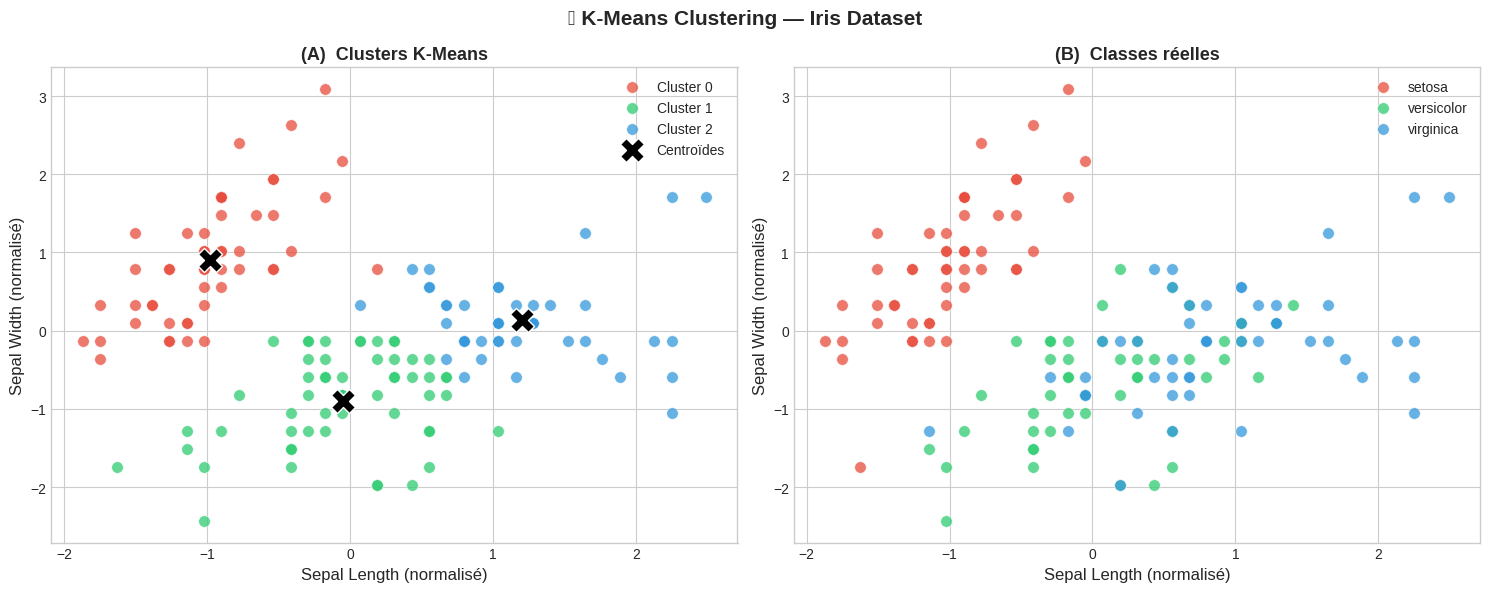

In [14]:
# ============================================================
#  🎨 Visualisation du Clustering (2D)
# ============================================================

# Recalcul sur X_viz_scaled pour cohérence visuelle
km_viz  = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
lbl_viz = km_viz.fit_predict(X_viz_scaled)
centers = km_viz.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("🌸 K-Means Clustering — Iris Dataset", fontsize=15, fontweight="bold")

cluster_names = [f"Cluster {i}" for i in range(K_OPTIMAL)]

# ── (A) Clusters K-Means ────────────────────────────────────
ax = axes[0]
for i in range(K_OPTIMAL):
    mask = lbl_viz == i
    ax.scatter(X_viz_scaled[mask, 0], X_viz_scaled[mask, 1],
               c=PALETTE[i], label=cluster_names[i],
               alpha=0.75, s=70, edgecolors="white", linewidth=0.5)

ax.scatter(centers[:, 0], centers[:, 1],
           marker="X", s=300, c="black",
           zorder=5, label="Centroïdes", edgecolors="white", linewidth=1)
ax.set_xlabel("Sepal Length (normalisé)", fontsize=12)
ax.set_ylabel("Sepal Width (normalisé)", fontsize=12)
ax.set_title("(A)  Clusters K-Means", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

# ── (B) Classes réelles ─────────────────────────────────────
ax2 = axes[1]
for i, name in enumerate(iris.target_names):
    mask = iris.target == i
    ax2.scatter(X_viz_scaled[mask, 0], X_viz_scaled[mask, 1],
                c=PALETTE[i], label=name,
                alpha=0.75, s=70, edgecolors="white", linewidth=0.5)

ax2.set_xlabel("Sepal Length (normalisé)", fontsize=12)
ax2.set_ylabel("Sepal Width (normalisé)", fontsize=12)
ax2.set_title("(B)  Classes réelles", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("clustering_result.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_9470/3518165409.py:45: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9470/3518165409.py:45: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9470/3518165409.py:45: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9470/3518165409.py:46: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig("silhouette_plot.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_9470/3518165409.py:46: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig("silhouette_plot.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_9470/3518165409.py:46: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Liberation Sans.
  plt.savefig("silhouette_plot.png", dpi=150, bbox_inches="tight")
/u

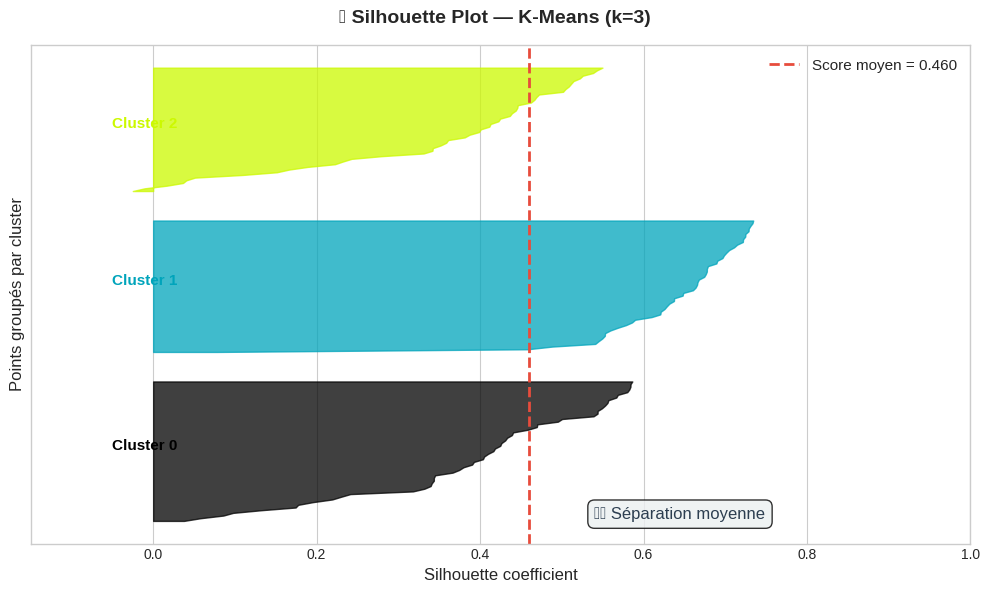


📌 Silhouette Score global : 0.4599


In [15]:
# ============================================================
#  🔬 Silhouette Plot  détaillé  (par point)
# ============================================================
sil_vals   = silhouette_samples(X_scaled, labels)
sil_avg    = silhouette_score(X_scaled, labels)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("🔬 Silhouette Plot — K-Means (k=3)",
             fontsize=14, fontweight="bold")

y_lower = 10
for i in range(K_OPTIMAL):
    ith_vals = np.sort(sil_vals[labels == i])
    size_i   = ith_vals.shape[0]
    y_upper  = y_lower + size_i

    color = cm.nipy_spectral(float(i) / K_OPTIMAL)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_vals,
                     facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.05, y_lower + 0.5 * size_i, f"Cluster {i}",
            fontsize=11, fontweight="bold", color=color)
    y_lower = y_upper + 10

# Ligne silhouette moyenne
ax.axvline(x=sil_avg, color="#E74C3C", linestyle="--", linewidth=2,
           label=f"Score moyen = {sil_avg:.3f}")

ax.set_xlabel("Silhouette coefficient", fontsize=12)
ax.set_ylabel("Points groupés par cluster", fontsize=12)
ax.set_xlim([-0.15, 1.0])
ax.set_yticks([])
ax.legend(fontsize=11, loc="upper right")

# Annotation interprétation
interpretation = (
    "✅ Bonne séparation" if sil_avg >= 0.5
    else "⚠️ Séparation moyenne" if sil_avg >= 0.25
    else "❌ Mauvaise séparation"
)
ax.text(0.60, 0.05, interpretation, transform=ax.transAxes,
        fontsize=12, color="#2C3E50",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#ECF0F1", alpha=0.8))

plt.tight_layout()
plt.savefig("silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📌 Silhouette Score global : {sil_avg:.4f}")